In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df_main = pd.read_csv('NBA Player Stats and Salaries_2010-2025.csv')
df_teams = pd.read_csv('NBA_TEAMS.csv')
df_seasons = pd.read_csv("all_seasons.csv")

In [3]:
# 1. Clean Column Names 
df_main.columns    = df_main.columns.str.strip().str.replace(' ', '_').str.replace('%', '_pct').str.lower()
df_teams.columns   = df_teams.columns.str.strip().str.lower()
df_seasons.columns = df_seasons.columns.str.strip().str.lower()

# 2. Masking and Feature Engineering
q_2014 = df_main[df_main['year'] == 2014]['3pa'].quantile(0.75)
q_2024 = df_main[df_main['year'] == 2024]['3pa'].quantile(0.75)

df_main['is_high_volume'] = False
df_main.loc[(df_main['year'] == 2014) & (df_main['3pa'] >= q_2014), 'is_high_volume'] = True
df_main.loc[(df_main['year'] == 2024) & (df_main['3pa'] >= q_2024), 'is_high_volume'] = True

# Salary cap percentage ROI
cap_map = {2014: 63065000, 2024: 140588000}
df_main['cap_pct'] = df_main.apply(
    lambda row: row['salary'] / cap_map.get(row['year'], np.nan), axis=1
)

df_viz = df_main[df_main['year'].isin([2014, 2024])].dropna(subset=['cap_pct'])

In [4]:
def simplify_pos(p):
    if not isinstance(p, str): return 'Unknown'
    primary = p.split('-')[0].strip().upper()
    return primary if primary in ['PG', 'SG', 'SF', 'PF', 'C'] else 'Unknown'

df_main['pos_simple'] = df_main['pos'].apply(simplify_pos)

# sal is a clean alias of df_main
sal = df_main.copy()

# Map salary-file year (end-year) to all_seasons season key
# e.g. year 2014 -> "2013-14", year 2021 -> "2020-21"
def year_to_season(y):
    return f'{y-1}-{str(y)[2:]}'

df_main['season_key'] = df_main['year'].apply(year_to_season)
sal['season_key']     = sal['year'].apply(year_to_season)

def norm_name(s): return str(s).strip().lower()

df_main['_key']    = df_main['player'].apply(norm_name)
sal['_key']        = sal['player'].apply(norm_name)
df_seasons['_key'] = df_seasons['player_name'].apply(norm_name)

ADV_COLS = ['_key', 'season', 'ast', 'net_rating', 'ts_pct',
            'ast_pct', 'usg_pct', 'oreb_pct', 'dreb_pct']

merged = df_main.merge(
    df_seasons[ADV_COLS],
    left_on=['_key', 'season_key'],
    right_on=['_key', 'season'],
    how='left'
).drop(columns=['_key', 'season'])

print(f"sal rows           : {len(sal)}")
print(f"merged rows        : {len(merged)}")
print(f"net_rating coverage: {merged['net_rating'].notna().mean():.1%}")
print(f"ast_x exists       : {'ast_x' in merged.columns}")
print(f"pos_simple counts  :\n{sal['pos_simple'].value_counts().head()}")

sal rows           : 7298
merged rows        : 7302
net_rating coverage: 85.7%
ast_x exists       : True
pos_simple counts  :
pos_simple
SG    1664
PF    1471
C     1422
PG    1374
SF    1367
Name: count, dtype: int64


Available columns in sal: ['fg_pct', '3pa', '3p_pct', 'fta', 'ft_pct', 'trb', 'ast', 'stl', 'blk', 'tov', 'pts']
Using metrics: ['3pa', '3p_pct', 'fta', 'trb']


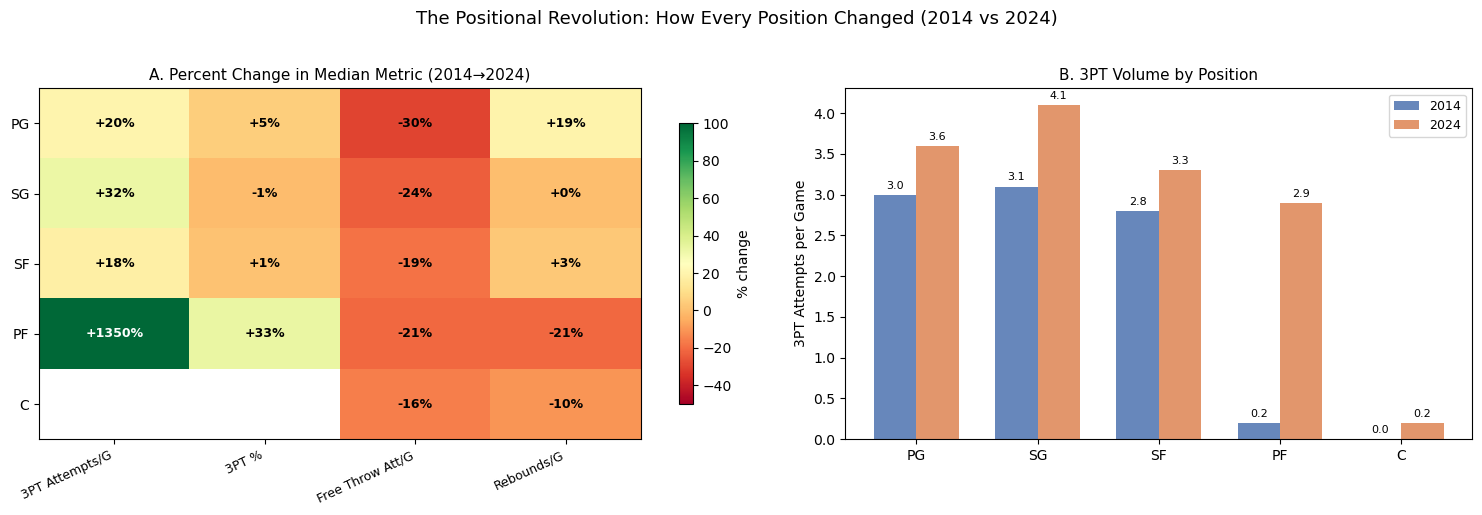

In [5]:
fig1_df = sal[sal['year'].isin([2014, 2024])].copy()
fig1_df = fig1_df[(fig1_df['g'] >= 20) & (fig1_df['mp'] >= 10)].copy()
fig1_df = fig1_df[fig1_df['pos_simple'].isin(['PG', 'SG', 'SF', 'PF', 'C'])]
 
# Detect which metrics are available in sal
# (Column names depend on your CSV; these are standard basketball-reference names)
print("Available columns in sal:", [c for c in sal.columns if c in
      ['3pa','3p_pct','fta','trb','ast','pts','stl','blk','tov','ft_pct','fg_pct']])
 
_candidates = [('3pa', '3PT Attempts/G'), ('3p_pct', '3PT %'),
               ('fta', 'Free Throw Att/G'), ('trb', 'Rebounds/G'),
               ('ast', 'Assists/G'), ('pts', 'Points/G')]
fig1_metrics, fig1_labels = [], []
for col, label in _candidates:
    if col in fig1_df.columns:
        fig1_metrics.append(col)
        fig1_labels.append(label)
if len(fig1_metrics) < 3:
    print("⚠️ Fewer than 3 metrics found. Check column names with: print(sal.columns.tolist())")
fig1_metrics = fig1_metrics[:4]   # cap at 4 for clean layout
fig1_labels  = fig1_labels[:4]
print(f"Using metrics: {fig1_metrics}")
 
# Compute medians and percent change
medians_2014 = fig1_df[fig1_df['year'] == 2014].groupby('pos_simple')[fig1_metrics].median()
medians_2024 = fig1_df[fig1_df['year'] == 2024].groupby('pos_simple')[fig1_metrics].median()
 
positions = ['PG', 'SG', 'SF', 'PF', 'C']
 
# ── Heatmap of % change ──
pct_change = ((medians_2024 - medians_2014) / medians_2014 * 100).reindex(positions)
pct_change.columns = fig1_labels
 
fig, axes = plt.subplots(1, 2, figsize=(15, 5),
                         gridspec_kw={'width_ratios': [1.2, 1]})
fig.suptitle(
    'The Positional Revolution: How Every Position Changed (2014 vs 2024)',
    fontsize=13, y=1.02
)
 
# Panel A: Heatmap of % change
ax = axes[0]
im = ax.imshow(pct_change.values, cmap='RdYlGn', aspect='auto', vmin=-50, vmax=100)
ax.set_xticks(range(len(fig1_labels)))
ax.set_xticklabels(fig1_labels, rotation=25, ha='right', fontsize=9)
ax.set_yticks(range(len(positions)))
ax.set_yticklabels(positions, fontsize=10)
for i in range(len(positions)):
    for j in range(len(fig1_labels)):
        val = pct_change.values[i, j]
        ax.text(j, i, f'{val:+.0f}%', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if abs(val) > 40 else 'black')
ax.set_title('A. Percent Change in Median Metric (2014→2024)', fontsize=11)
fig.colorbar(im, ax=ax, shrink=0.8, label='% change')
 
# Panel B: Grouped bar for 3PA specifically (the defining shift)
ax = axes[1]
x = np.arange(len(positions))
width = 0.35
bars_14 = ax.bar(x - width/2,
                 [medians_2014.loc[p, '3pa'] for p in positions],
                 width, label='2014', color='#4C72B0', alpha=0.85)
bars_24 = ax.bar(x + width/2,
                 [medians_2024.loc[p, '3pa'] for p in positions],
                 width, label='2024', color='#DD8452', alpha=0.85)
 
for bars in [bars_14, bars_24]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.05,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8)
 
ax.set_xticks(x)
ax.set_xticklabels(positions)
ax.set_ylabel('3PT Attempts per Game')
ax.set_title('B. 3PT Volume by Position', fontsize=11)
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.show()

Using columns: ts_pct→ts_pct, ast→ast_x


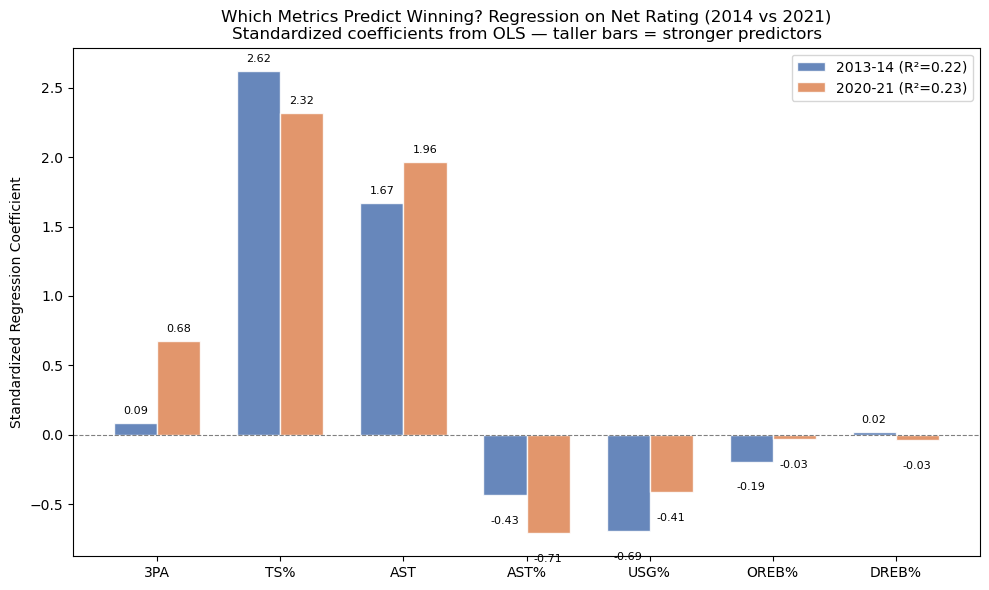


── Standardized Coefficients ──
       2013-14  2020-21      Δ          Direction
3PA      0.088    0.679  0.592  ↑ more predictive
TS%      2.621    2.321 -0.301  ↓ less predictive
AST      1.669    1.964  0.295  ↑ more predictive
AST%    -0.433   -0.708 -0.275  ↓ less predictive
USG%    -0.694   -0.414  0.280  ↑ more predictive
OREB%   -0.192   -0.029  0.163  ↑ more predictive
DREB%    0.019   -0.035 -0.054  ↓ less predictive

R² 2014: 0.224   R² 2021: 0.226


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
 
# Resolve column names (handle possible _x/_y suffixes from merge)
def find_col(df, base_name):
    """Find a column even if pandas added _x or _y suffix."""
    if base_name in df.columns:
        return base_name
    for suffix in ['_x', '_y']:
        if base_name + suffix in df.columns:
            return base_name + suffix
    return None
 
TS_COL  = find_col(merged, 'ts_pct')
AST_COL = find_col(merged, 'ast')      # likely ast_x
if AST_COL is None:
    AST_COL = 'ast_x'                   # fallback
 
print(f"Using columns: ts_pct→{TS_COL}, ast→{AST_COL}")
 
reg_df = merged[merged['year'].isin([2014, 2021])].copy()
reg_df = reg_df[(reg_df['g'] >= 20) & (reg_df['mp'] >= 10)].copy()
reg_df = reg_df.dropna(subset=['net_rating', TS_COL, AST_COL, 'ast_pct',
                                'usg_pct', '3pa', 'oreb_pct', 'dreb_pct'])
 
features = {
    '3PA':       '3pa',
    'TS%':       TS_COL,
    'AST':       AST_COL,
    'AST%':      'ast_pct',
    'USG%':      'usg_pct',
    'OREB%':     'oreb_pct',
    'DREB%':     'dreb_pct',
}
feat_names = list(features.keys())
feat_cols  = list(features.values())
 
coefs = {}
r2s   = {}
 
for yr in [2014, 2021]:
    subset = reg_df[reg_df['year'] == yr].copy()
 
    X = subset[feat_cols].values
    y = subset['net_rating'].values
 
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
 
    model = LinearRegression().fit(X_scaled, y)
    coefs[yr] = model.coef_
    r2s[yr]   = model.score(X_scaled, y)
 
# ── Plot: side-by-side standardized coefficients ──
fig, ax = plt.subplots(figsize=(10, 6))
 
x = np.arange(len(feat_names))
width = 0.35
 
bars_14 = ax.bar(x - width/2, coefs[2014], width, label=f'2013-14 (R²={r2s[2014]:.2f})',
                 color='#4C72B0', alpha=0.85, edgecolor='white')
bars_21 = ax.bar(x + width/2, coefs[2021], width, label=f'2020-21 (R²={r2s[2021]:.2f})',
                 color='#DD8452', alpha=0.85, edgecolor='white')
 
for bars in [bars_14, bars_21]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + (0.05 if h >= 0 else -0.15),
                f'{h:.2f}', ha='center', va='bottom' if h >= 0 else 'top',
                fontsize=8)
 
ax.set_xticks(x)
ax.set_xticklabels(feat_names, fontsize=10)
ax.set_ylabel('Standardized Regression Coefficient', fontsize=10)
ax.set_title(
    'Which Metrics Predict Winning? Regression on Net Rating (2014 vs 2021)\n'
    'Standardized coefficients from OLS — taller bars = stronger predictors',
    fontsize=12
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.legend(fontsize=10)
 
plt.tight_layout()
plt.show()
 
# Print the numbers for your report
print("\n── Standardized Coefficients ──")
coef_table = pd.DataFrame({
    '2013-14': coefs[2014],
    '2020-21': coefs[2021],
}, index=feat_names)
coef_table['Δ'] = coef_table['2020-21'] - coef_table['2013-14']
coef_table['Direction'] = coef_table['Δ'].apply(
    lambda d: '↑ more predictive' if d > 0.05 else ('↓ less predictive' if d < -0.05 else '≈ stable')
)
print(coef_table.round(3).to_string())
print(f"\nR² 2014: {r2s[2014]:.3f}   R² 2021: {r2s[2021]:.3f}")

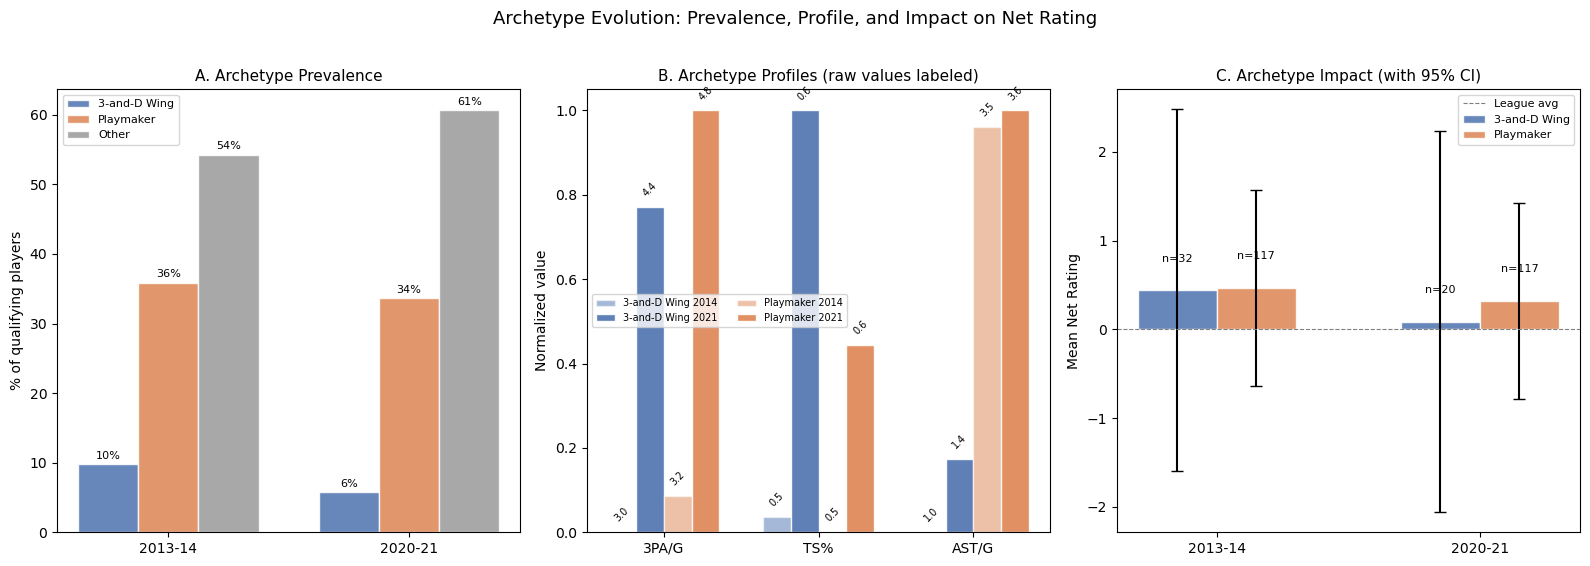


── Archetype Net Rating Summary ──
 year    archetype  mean_net   se_net   n       ci
 2014 3-and-D Wing  0.440625 1.038472  32 2.035406
 2014    Playmaker  0.465812 0.560902 117 1.099368
 2021 3-and-D Wing  0.085000 1.093745  20 2.143740
 2021    Playmaker  0.319658 0.561475 117 1.100490


In [7]:
arch_df = merged[merged['year'].isin([2014, 2021])].copy()
arch_df = arch_df[(arch_df['g'] >= 20) & (arch_df['mp'] >= 10)].copy()
arch_df = arch_df.dropna(subset=[TS_COL, '3pa', AST_COL, 'ast_pct', 'net_rating'])
arch_df['archetype'] = 'Other'
 
for yr in [2014, 2021]:
    ym = arch_df['year'] == yr
    sd = arch_df[ym]
 
    med_3pa  = sd['3pa'].median()
    med_3pp  = sd['3p_pct'].median()
    med_ast  = sd[AST_COL].median()
    med_apct = sd['ast_pct'].median()
 
    wing = (ym
            & arch_df['pos_simple'].isin(['SG', 'SF'])
            & (arch_df['3pa']    >= med_3pa)
            & (arch_df['3p_pct'] >= med_3pp)
            & (arch_df[AST_COL]  <  med_ast))
 
    play = (ym
            & arch_df['pos_simple'].isin(['PG', 'SG', 'SF'])
            & (arch_df[AST_COL]  >= med_ast)
            & (arch_df['ast_pct'] >= med_apct))
 
    arch_df.loc[wing, 'archetype'] = '3-and-D Wing'
    arch_df.loc[play, 'archetype'] = 'Playmaker'
 
colors_arch = {'3-and-D Wing': '#4C72B0', 'Playmaker': '#DD8452', 'Other': '#999999'}
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle(
    'Archetype Evolution: Prevalence, Profile, and Impact on Net Rating',
    fontsize=13, y=1.02
)
 
# ── Panel A: Archetype prevalence (% of roster) ──
ax = axes[0]
prev = (
    arch_df.groupby(['year', 'archetype']).size()
    .reset_index(name='n')
)
totals = arch_df.groupby('year').size().reset_index(name='total')
prev = prev.merge(totals, on='year')
prev['pct'] = prev['n'] / prev['total'] * 100
 
x = np.arange(2)
width = 0.25
for i, arch in enumerate(['3-and-D Wing', 'Playmaker', 'Other']):
    vals = []
    for yr in [2014, 2021]:
        row = prev[(prev['archetype'] == arch) & (prev['year'] == yr)]
        vals.append(row['pct'].values[0] if len(row) > 0 else 0)
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=arch,
                  color=colors_arch[arch], alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        if h > 2:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.0f}%', ha='center', va='bottom', fontsize=8)
 
ax.set_xticks(x)
ax.set_xticklabels(['2013-14', '2020-21'])
ax.set_ylabel('% of qualifying players')
ax.set_title('A. Archetype Prevalence', fontsize=11)
ax.legend(fontsize=8)
 
# ── Panel B: Key metrics by archetype (radar-like grouped bar) ──
ax = axes[1]
arch_only = arch_df[arch_df['archetype'].isin(['3-and-D Wing', 'Playmaker'])]
profile_metrics = ['3pa', TS_COL, AST_COL]
profile_labels  = ['3PA/G', 'TS%', 'AST/G']
 
med_prof = arch_only.groupby(['year', 'archetype'])[profile_metrics].median().reset_index()
 
# Normalize each metric to 0-1 for comparable display
for m in profile_metrics:
    vmin = med_prof[m].min()
    vmax = med_prof[m].max()
    med_prof[m + '_norm'] = (med_prof[m] - vmin) / (vmax - vmin) if vmax > vmin else 0.5
 
x = np.arange(len(profile_labels))
width = 0.18
combos = [(2014, '3-and-D Wing'), (2021, '3-and-D Wing'),
          (2014, 'Playmaker'),    (2021, 'Playmaker')]
alphas = [0.5, 0.9, 0.5, 0.9]
hatches = ['', '', '', '']
 
for i, ((yr, arch), alpha) in enumerate(zip(combos, alphas)):
    row = med_prof[(med_prof['year'] == yr) & (med_prof['archetype'] == arch)]
    if len(row) == 0:
        continue
    vals = [row[m + '_norm'].values[0] for m in profile_metrics]
    raw  = [row[m].values[0] for m in profile_metrics]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width,
                  label=f'{arch} {yr}',
                  color=colors_arch[arch], alpha=alpha, edgecolor='white')
    for bar, rv in zip(bars, raw):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{rv:.1f}', ha='center', va='bottom', fontsize=7, rotation=45)
 
ax.set_xticks(x)
ax.set_xticklabels(profile_labels, fontsize=10)
ax.set_ylabel('Normalized value')
ax.set_title('B. Archetype Profiles (raw values labeled)', fontsize=11)
ax.legend(fontsize=7, ncol=2)
 
# ── Panel C: Net Rating by archetype per era (THE KEY PANEL) ──
ax = axes[2]
arch_net = (
    arch_df[arch_df['archetype'] != 'Other']
    .groupby(['year', 'archetype'])
    .agg(
        mean_net = ('net_rating', 'mean'),
        se_net   = ('net_rating', lambda s: s.std(ddof=1) / np.sqrt(len(s))),
        n        = ('net_rating', 'size')
    )
    .reset_index()
)
arch_net['ci'] = 1.96 * arch_net['se_net']
 
x = np.arange(2)
width = 0.3
 
for i, arch in enumerate(['3-and-D Wing', 'Playmaker']):
    sub = arch_net[arch_net['archetype'] == arch].set_index('year')
    vals = [sub.loc[yr, 'mean_net'] if yr in sub.index else 0 for yr in [2014, 2021]]
    cis  = [sub.loc[yr, 'ci']       if yr in sub.index else 0 for yr in [2014, 2021]]
    ns   = [int(sub.loc[yr, 'n'])   if yr in sub.index else 0 for yr in [2014, 2021]]
 
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, vals, width, yerr=cis, capsize=4,
                  label=arch, color=colors_arch[arch], alpha=0.85, edgecolor='white')
    for bar, n in zip(bars, ns):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + (0.3 if h >= 0 else -0.5),
                f'n={n}', ha='center', va='bottom' if h >= 0 else 'top', fontsize=8)
 
ax.set_xticks(x)
ax.set_xticklabels(['2013-14', '2020-21'])
ax.set_ylabel('Mean Net Rating')
ax.set_title('C. Archetype Impact (with 95% CI)', fontsize=11)
ax.axhline(0, color='grey', lw=0.8, ls='--', label='League avg')
ax.legend(fontsize=8)
 
plt.tight_layout()
plt.show()
 
# Print for report
print("\n── Archetype Net Rating Summary ──")
print(arch_net.to_string(index=False))

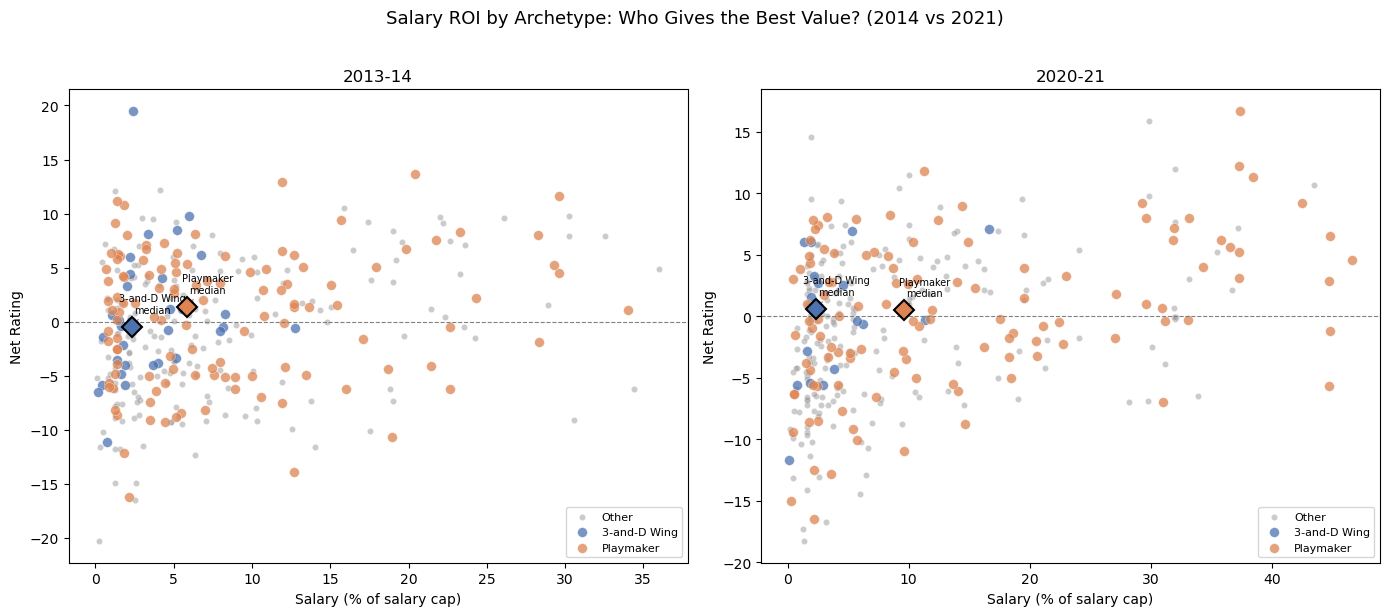

In [8]:
roi_df = merged[merged['year'].isin([2014, 2021])].copy()
roi_df = roi_df[(roi_df['g'] >= 20) & (roi_df['mp'] >= 10)].copy()
roi_df = roi_df.dropna(subset=['net_rating', 'salary'])
 
# Extend cap_map if 2021 is missing
cap_map_ext = {2014: 63065000, 2021: 112414000, 2024: 140588000}
roi_df['cap_pct'] = roi_df.apply(
    lambda r: r['salary'] / cap_map_ext.get(r['year'], np.nan), axis=1
)
roi_df = roi_df.dropna(subset=['cap_pct'])
 
# Reuse archetype classification
roi_df['archetype'] = 'Other'
for yr in [2014, 2021]:
    ym = roi_df['year'] == yr
    sd = roi_df[ym]
 
    med_3pa  = sd['3pa'].median()
    med_3pp  = sd['3p_pct'].median()
    med_ast  = sd[AST_COL].median()
    med_apct = sd['ast_pct'].median()
 
    wing = (ym
            & roi_df['pos_simple'].isin(['SG', 'SF'])
            & (roi_df['3pa']    >= med_3pa)
            & (roi_df['3p_pct'] >= med_3pp)
            & (roi_df[AST_COL]  <  med_ast))
 
    play = (ym
            & roi_df['pos_simple'].isin(['PG', 'SG', 'SF'])
            & (roi_df[AST_COL]  >= med_ast)
            & (roi_df['ast_pct'] >= med_apct))
 
    roi_df.loc[wing, 'archetype'] = '3-and-D Wing'
    roi_df.loc[play, 'archetype'] = 'Playmaker'
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Salary ROI by Archetype: Who Gives the Best Value? (2014 vs 2021)',
    fontsize=13, y=1.02
)
 
# ── Panel A: Scatter — cap% vs net rating, colored by archetype ──
for ax, yr, yr_label in zip(axes, [2014, 2021], ['2013-14', '2020-21']):
    sub = roi_df[roi_df['year'] == yr]
 
    for arch in ['Other', '3-and-D Wing', 'Playmaker']:
        a = sub[sub['archetype'] == arch]
        ax.scatter(a['cap_pct'] * 100, a['net_rating'],
                   color=colors_arch[arch], alpha=0.5 if arch == 'Other' else 0.75,
                   s=20 if arch == 'Other' else 50,
                   label=arch, edgecolors='white', lw=0.3)
 
    # Add median markers for each archetype
    for arch in ['3-and-D Wing', 'Playmaker']:
        a = sub[sub['archetype'] == arch]
        if len(a) > 0:
            mx = a['cap_pct'].median() * 100
            my = a['net_rating'].median()
            ax.plot(mx, my, marker='D', markersize=10, color=colors_arch[arch],
                    markeredgecolor='black', markeredgewidth=1.5, zorder=5)
            ax.annotate(f'{arch}\nmedian',
                        (mx, my), fontsize=7, ha='center',
                        xytext=(15, 10), textcoords='offset points',
                        arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))
 
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xlabel('Salary (% of salary cap)')
    ax.set_ylabel('Net Rating')
    ax.set_title(yr_label, fontsize=12)
    ax.legend(fontsize=8, loc='lower right')
 
plt.tight_layout()
plt.show()

AI DISCLOSURE FOR VISUALIZATION 4: Used ai for methodology and conceptualization for how visualization should look and how to write the code (FORMAT BETTER)

DISCLAIMER: Figs 2–4 use 2021 instead of 2024 because  all_seasons.csv only covers through the 2020-21 season (that's where net_rating comes from). 